0 26.045337677001953
100 4.033066272735596
200 2.7523553371429443
300 1.4939056634902954
400 1.2822574377059937
500 0.9382534027099609
600 1.0291374921798706
700 0.9103321433067322
800 0.944231390953064
900 0.9879004955291748
1000 0.9336064457893372
1100 1.042659044265747
1200 1.0610952377319336
1300 0.8909719586372375
1400 0.9383576512336731
1500 0.9687042236328125
1600 1.0965293645858765
1700 0.7965904474258423
1800 0.8222819566726685
1900 0.9186534881591797
2000 1.074984073638916
2100 0.7428228855133057
2200 0.6135174632072449
2300 0.8514237999916077
2400 0.7801443934440613
2500 0.6624484062194824
2600 0.6630958318710327
2700 0.7024344205856323
2800 0.8374361395835876
2900 0.7779582142829895


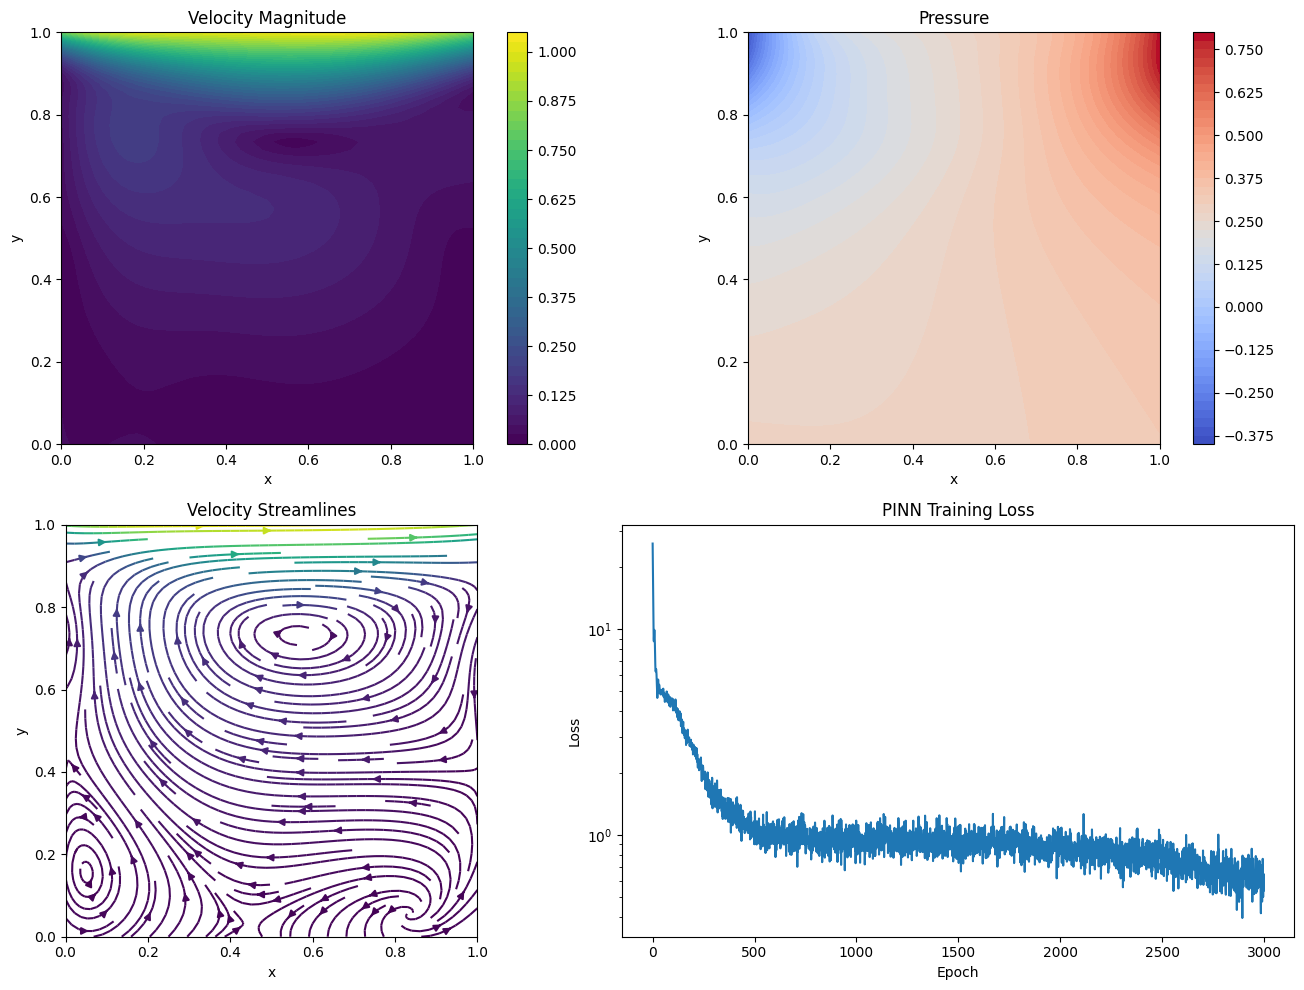

In [1]:
import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


# ============================================================
# 1. Device
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

torch.manual_seed(0)
np.random.seed(0)


# ============================================================
# 2. PINN
#
# (x, y) -> (u, v, p)
# ============================================================

class PINN(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(2, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 3)
        )


    def forward(self, x):

        return self.net(x)


model = PINN().to(device)


# ============================================================
# 3. Gradient
# ============================================================

def grad(y, x):

    return torch.autograd.grad(

        y,
        x,

        grad_outputs=torch.ones_like(y),

        create_graph=True,
        retain_graph=True

    )[0]


# ============================================================
# 4. Navier-Stokes Physics
#
# continuity
#
# u_x + v_y = 0
#
#
# momentum x
#
# u u_x + v u_y
# + p_x
# - nu (u_xx + u_yy) = 0
#
#
# momentum y
#
# u v_x + v v_y
# + p_y
# - nu (v_xx + v_yy) = 0
#
# ============================================================

def physics_loss(
    model,
    xy,
    nu
):

    xy.requires_grad_(True)

    output = model(xy)

    u = output[:, 0:1]
    v = output[:, 1:2]
    p = output[:, 2:3]


    # first derivatives
    u_grad = grad(u, xy)
    v_grad = grad(v, xy)
    p_grad = grad(p, xy)


    u_x = u_grad[:, 0:1]
    u_y = u_grad[:, 1:2]

    v_x = v_grad[:, 0:1]
    v_y = v_grad[:, 1:2]

    p_x = p_grad[:, 0:1]
    p_y = p_grad[:, 1:2]


    # second derivatives
    u_xx = grad(
        u_x,
        xy
    )[:, 0:1]

    u_yy = grad(
        u_y,
        xy
    )[:, 1:2]


    v_xx = grad(
        v_x,
        xy
    )[:, 0:1]

    v_yy = grad(
        v_y,
        xy
    )[:, 1:2]


    # ========================================================
    # PDE residual
    # ========================================================

    continuity = (
        u_x
        + v_y
    )


    momentum_x = (

        u * u_x

        + v * u_y

        + p_x

        - nu * (
            u_xx
            + u_yy
        )
    )


    momentum_y = (

        u * v_x

        + v * v_y

        + p_y

        - nu * (
            v_xx
            + v_yy
        )
    )


    return (

        torch.mean(
            continuity ** 2
        )

        +

        torch.mean(
            momentum_x ** 2
        )

        +

        torch.mean(
            momentum_y ** 2
        )
    )


# ============================================================
# 5. Boundary condition
#
#
#        u = 1
#     -------------->
#     |            |
#     |            |
#     |            |
#     |            |
#     --------------
#
#
# top:
# u = 1
# v = 0
#
# other walls:
# u = 0
# v = 0
#
# ============================================================

def boundary_loss(
    model,
    N=200
):

    # --------------------------------------------------------
    # top
    # --------------------------------------------------------

    x = torch.rand(
        N,
        1,
        device=device
    )

    y = torch.ones(
        N,
        1,
        device=device
    )

    top = torch.cat(
        [x, y],
        dim=1
    )

    top_output = model(top)

    top_u = top_output[:, 0:1]
    top_v = top_output[:, 1:2]


    loss_top = (

        torch.mean(
            (top_u - 1) ** 2
        )

        +

        torch.mean(
            top_v ** 2
        )
    )


    # --------------------------------------------------------
    # bottom
    # --------------------------------------------------------

    x = torch.rand(
        N,
        1,
        device=device
    )

    y = torch.zeros(
        N,
        1,
        device=device
    )

    bottom = torch.cat(
        [x, y],
        dim=1
    )

    bottom_output = model(bottom)

    loss_bottom = torch.mean(
        bottom_output[:, 0:2] ** 2
    )


    # --------------------------------------------------------
    # left
    # --------------------------------------------------------

    x = torch.zeros(
        N,
        1,
        device=device
    )

    y = torch.rand(
        N,
        1,
        device=device
    )

    left = torch.cat(
        [x, y],
        dim=1
    )

    left_output = model(left)

    loss_left = torch.mean(
        left_output[:, 0:2] ** 2
    )


    # --------------------------------------------------------
    # right
    # --------------------------------------------------------

    x = torch.ones(
        N,
        1,
        device=device
    )

    y = torch.rand(
        N,
        1,
        device=device
    )

    right = torch.cat(
        [x, y],
        dim=1
    )

    right_output = model(right)

    loss_right = torch.mean(
        right_output[:, 0:2] ** 2
    )


    return (

        loss_top
        + loss_bottom
        + loss_left
        + loss_right
    )


# ============================================================
# 6. Training
# ============================================================

Re = 20.0

nu = 1.0 / Re


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)


epochs = 3000

N_interior = 1000


loss_history = []

# 시각화용 snapshot
snapshots = []


for epoch in range(epochs):

    optimizer.zero_grad()


    # --------------------------------------------------------
    # random collocation points
    # --------------------------------------------------------

    xy = torch.rand(
        N_interior,
        2,
        device=device
    )


    loss_pde = physics_loss(
        model,
        xy,
        nu
    )


    loss_bc = boundary_loss(
        model,
        N=200
    )


    # --------------------------------------------------------
    # Total loss
    # --------------------------------------------------------

    loss = (

        loss_pde

        + 20.0
        * loss_bc
    )


    loss.backward()

    optimizer.step()


    loss_history.append(
        loss.item()
    )


    # --------------------------------------------------------
    # snapshot
    # --------------------------------------------------------

    if epoch % 100 == 0:

        print(
            epoch,
            loss.item()
        )

        snapshots.append(
            {
                "epoch": epoch,
                "state_dict": {
                    k: v.detach().cpu().clone()
                    for k, v
                    in model.state_dict().items()
                }
            }
        )


# ============================================================
# 7. Grid
# ============================================================

resolution = 50


x = np.linspace(
    0,
    1,
    resolution
)

y = np.linspace(
    0,
    1,
    resolution
)


X, Y = np.meshgrid(
    x,
    y
)


XY = np.array([

    X.flatten(),

    Y.flatten()

]).T


XY_tensor = torch.tensor(

    XY,

    dtype=torch.float32,

    device=device
)


# ============================================================
# 8. Evaluate model
# ============================================================

def evaluate():

    model.eval()

    with torch.no_grad():

        pred = model(
            XY_tensor
        ).cpu().numpy()


    U = pred[:, 0].reshape(
        resolution,
        resolution
    )


    V = pred[:, 1].reshape(
        resolution,
        resolution
    )


    P = pred[:, 2].reshape(
        resolution,
        resolution
    )


    velocity = np.sqrt(
        U ** 2
        + V ** 2
    )


    return (
        U,
        V,
        P,
        velocity
    )


# ============================================================
# 9. Static Matplotlib visualization
# ============================================================

U, V, P, velocity = evaluate()


fig = plt.figure(
    figsize=(14, 10)
)


# ------------------------------------------------------------
# Velocity magnitude
# ------------------------------------------------------------

ax1 = fig.add_subplot(
    2,
    2,
    1
)

contour = ax1.contourf(

    X,
    Y,
    velocity,

    levels=50,

    cmap="viridis"
)

fig.colorbar(
    contour,
    ax=ax1
)

ax1.set_title(
    "Velocity Magnitude"
)

ax1.set_xlabel("x")
ax1.set_ylabel("y")

ax1.set_aspect(
    "equal"
)


# ------------------------------------------------------------
# Pressure
# ------------------------------------------------------------

ax2 = fig.add_subplot(
    2,
    2,
    2
)

contour = ax2.contourf(

    X,
    Y,
    P,

    levels=50,

    cmap="coolwarm"
)

fig.colorbar(
    contour,
    ax=ax2
)

ax2.set_title(
    "Pressure"
)

ax2.set_xlabel("x")
ax2.set_ylabel("y")

ax2.set_aspect(
    "equal"
)


# ------------------------------------------------------------
# Flow / streamplot
# ------------------------------------------------------------

ax3 = fig.add_subplot(
    2,
    2,
    3
)

ax3.streamplot(

    X,
    Y,

    U,
    V,

    density=1.5,

    color=velocity,

    cmap="viridis"
)

ax3.set_title(
    "Velocity Streamlines"
)

ax3.set_xlabel("x")
ax3.set_ylabel("y")

ax3.set_xlim(
    0,
    1
)

ax3.set_ylim(
    0,
    1
)

ax3.set_aspect(
    "equal"
)


# ------------------------------------------------------------
# Loss
# ------------------------------------------------------------

ax4 = fig.add_subplot(
    2,
    2,
    4
)

ax4.plot(
    loss_history
)

ax4.set_yscale(
    "log"
)

ax4.set_title(
    "PINN Training Loss"
)

ax4.set_xlabel(
    "Epoch"
)

ax4.set_ylabel(
    "Loss"
)


plt.tight_layout()

plt.show()

In [3]:
# ============================================================
# 10. Matplotlib Animation -> HTML
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 6)
)


def update(frame):

    ax.clear()

    snapshot = snapshots[frame]


    # snapshot weight load
    model.load_state_dict(
        snapshot["state_dict"]
    )

    model.to(device)


    U, V, P, velocity = evaluate()


    # --------------------------------------------------------
    # Velocity magnitude
    # --------------------------------------------------------

    ax.contourf(

        X,
        Y,
        velocity,

        levels=30,

        cmap="viridis"
    )


    # --------------------------------------------------------
    # Stream lines
    # --------------------------------------------------------

    ax.streamplot(

        X,
        Y,

        U,
        V,

        density=1.2,

        linewidth=0.8,

        color="white"
    )


    ax.set_title(
        f"PINN Navier-Stokes\n"
        f"Epoch = {snapshot['epoch']}"
    )


    ax.set_xlabel("x")
    ax.set_ylabel("y")


    ax.set_xlim(
        0,
        1
    )

    ax.set_ylim(
        0,
        1
    )


    ax.set_aspect(
        "equal"
    )


animation = FuncAnimation(

    fig,

    update,

    frames=len(
        snapshots
    ),

    interval=200
)


plt.close(fig)


# ============================================================
# Jupyter display
# ============================================================

HTML(
    animation.to_jshtml()
)

device: cpu
CFD step   10/250 | t = 0.020
CFD step   20/250 | t = 0.040
CFD step   30/250 | t = 0.060
CFD step   40/250 | t = 0.080
CFD step   50/250 | t = 0.100
CFD step   60/250 | t = 0.120
CFD step   70/250 | t = 0.140
CFD step   80/250 | t = 0.160
CFD step   90/250 | t = 0.180
CFD step  100/250 | t = 0.200
CFD step  110/250 | t = 0.220
CFD step  120/250 | t = 0.240
CFD step  130/250 | t = 0.260
CFD step  140/250 | t = 0.280
CFD step  150/250 | t = 0.300
CFD step  160/250 | t = 0.320
CFD step  170/250 | t = 0.340
CFD step  180/250 | t = 0.360
CFD step  190/250 | t = 0.380
CFD step  200/250 | t = 0.400
CFD step  210/250 | t = 0.420
CFD step  220/250 | t = 0.440
CFD step  230/250 | t = 0.460
CFD step  240/250 | t = 0.480
CFD step  250/250 | t = 0.500
saved frames: 26
sparse data: torch.Size([6500, 3]) torch.Size([6500, 3])
Epoch    1 | Total 1.2674e+01 | PDE 2.4913e-01 | BC 5.7994e-01 | IC 3.1042e-02 | Data 2.9623e-02
Epoch  200 | Total 1.4942e+00 | PDE 6.4427e-02 | BC 5.3459e-02 | IC

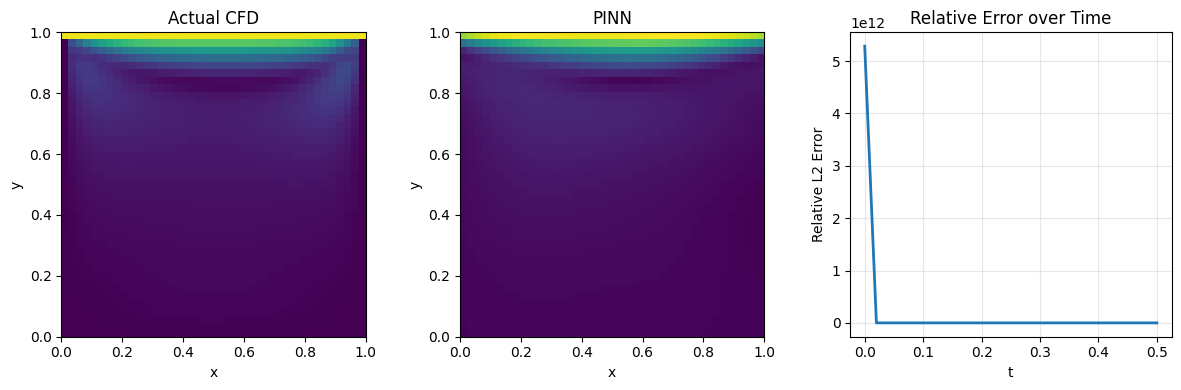

Saved: unsteady_cavity_pinn_vs_cfd.html


<Figure size 640x480 with 0 Axes>

In [ ]:
# ============================================================
# Matplotlib HTML animation
#
# Top-left:
#     Actual CFD streamlines
#
# Top-right:
#     PINN streamlines
#
# Bottom-left:
#     CFD vs PINN velocity overlay
#
# Bottom-right:
#     Relative error
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10),
)

ax_actual = axes[0, 0]
ax_pinn = axes[0, 1]
ax_overlay = axes[1, 0]
ax_error = axes[1, 1]


q_step = 4

Xq = X[::q_step, ::q_step]
Yq = Y[::q_step, ::q_step]


# ============================================================
# Global velocity magnitude
#
# color scale을 모든 frame에서 동일하게 유지
# ============================================================

global_speed_max = max(
    np.max(np.array(speed_cfd_frames)),
    np.max(np.array(speed_pinn_frames)),
)


# ============================================================
# Animation update
# ============================================================

def update(frame_idx):
    ax_actual.clear()
    ax_pinn.clear()
    ax_overlay.clear()
    ax_error.clear()

    t_value = times[frame_idx]

    # --------------------------------------------------------
    # CFD
    # --------------------------------------------------------

    u_cfd = cfd_u_frames[frame_idx]
    v_cfd = cfd_v_frames[frame_idx]

    speed_cfd = np.sqrt(
        u_cfd**2 + v_cfd**2
    )

    # --------------------------------------------------------
    # PINN
    # --------------------------------------------------------

    u_pinn = pinn_u_frames[frame_idx]
    v_pinn = pinn_v_frames[frame_idx]

    speed_pinn = np.sqrt(
        u_pinn**2 + v_pinn**2
    )

    # ========================================================
    # 1. Actual CFD streamplot
    # ========================================================

    ax_actual.streamplot(
        X,
        Y,
        u_cfd,
        v_cfd,
        color=speed_cfd,
        cmap="viridis",
        density=1.5,
        linewidth=1.2,
    )

    ax_actual.set_title(
        f"Actual CFD\n"
        f"t = {t_value:.3f}"
    )

    ax_actual.set_xlabel("x")
    ax_actual.set_ylabel("y")

    ax_actual.set_xlim(0, 1)
    ax_actual.set_ylim(0, 1)

    ax_actual.set_aspect("equal")


    # ========================================================
    # 2. PINN streamplot
    # ========================================================

    ax_pinn.streamplot(
        X,
        Y,
        u_pinn,
        v_pinn,
        color=speed_pinn,
        cmap="viridis",
        density=1.5,
        linewidth=1.2,
    )

    ax_pinn.set_title(
        f"PINN\n"
        f"t = {t_value:.3f}"
    )

    ax_pinn.set_xlabel("x")
    ax_pinn.set_ylabel("y")

    ax_pinn.set_xlim(0, 1)
    ax_pinn.set_ylim(0, 1)

    ax_pinn.set_aspect("equal")


    # ========================================================
    # 3. CFD vs PINN overlay
    #
    # Blue:
    #     actual CFD
    #
    # Orange:
    #     PINN
    # ========================================================

    ax_overlay.quiver(
        Xq,
        Yq,
        u_cfd[::q_step, ::q_step],
        v_cfd[::q_step, ::q_step],
        color="tab:blue",
        alpha=0.8,
        scale=12,
        width=0.004,
    )

    ax_overlay.quiver(
        Xq,
        Yq,
        u_pinn[::q_step, ::q_step],
        v_pinn[::q_step, ::q_step],
        color="tab:orange",
        alpha=0.8,
        scale=12,
        width=0.004,
    )

    # legend dummy
    ax_overlay.plot(
        [],
        [],
        color="tab:blue",
        label="Actual CFD",
    )

    ax_overlay.plot(
        [],
        [],
        color="tab:orange",
        label="PINN",
    )

    ax_overlay.set_title(
        "Velocity Vector Comparison"
    )

    ax_overlay.set_xlabel("x")
    ax_overlay.set_ylabel("y")

    ax_overlay.set_xlim(0, 1)
    ax_overlay.set_ylim(0, 1)

    ax_overlay.set_aspect("equal")

    ax_overlay.legend(
        loc="upper right"
    )


    # ========================================================
    # 4. Error
    # ========================================================

    ax_error.plot(
        times,
        relative_errors,
        color="black",
        linewidth=2,
    )

    ax_error.axvline(
        t_value,
        linestyle="--",
        linewidth=1.5,
    )

    ax_error.scatter(
        [t_value],
        [relative_errors[frame_idx]],
        s=50,
    )

    ax_error.set_title(
        "Relative Velocity Error"
    )

    ax_error.set_xlabel("t")

    ax_error.set_ylabel(
        r"$\|V_{PINN} - V_{CFD}\|_2"
        r" / "
        r"$\|V_{CFD}\|_2$"
    )

    ax_error.grid(
        alpha=0.3
    )

    ax_error.text(
        0.03,
        0.92,
        (
            f"error = "
            f"{relative_errors[frame_idx]:.4e}"
        ),
        transform=ax_error.transAxes,
    )


    # ========================================================
    # Figure title
    # ========================================================

    fig.suptitle(
        "Unsteady Lid-Driven Cavity\n"
        "Numerical Propagation vs PINN",
        fontsize=15,
    )

    plt.tight_layout()


# ============================================================
# Create animation
# ============================================================

animation = FuncAnimation(
    fig,
    update,
    frames=len(times),
    interval=250,
    blit=False,
)

plt.close(fig)


# ============================================================
# HTML
# ============================================================

html = animation.to_jshtml()

with open(
    "cavity_cfd_vs_pinn.html",
    "w",
    encoding="utf-8",
) as file:
    file.write(html)


display(
    HTML(html)
)